In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
from eyewire2_functional_analysis import data_loader

In [4]:
data_root = "../../../data"
data_folder = f"{data_root}/preprocessed-data"
morph_folder = f"{data_root}/morphological-data"
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv']


In [5]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv',
    nuc_col_master='Final NucID',
    seg_col_master=(
        'Updated Seg ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!',
        'Updated Seg ID (Sept 2)',
        'Final SegID'),
    df_rois=df_rois,
)

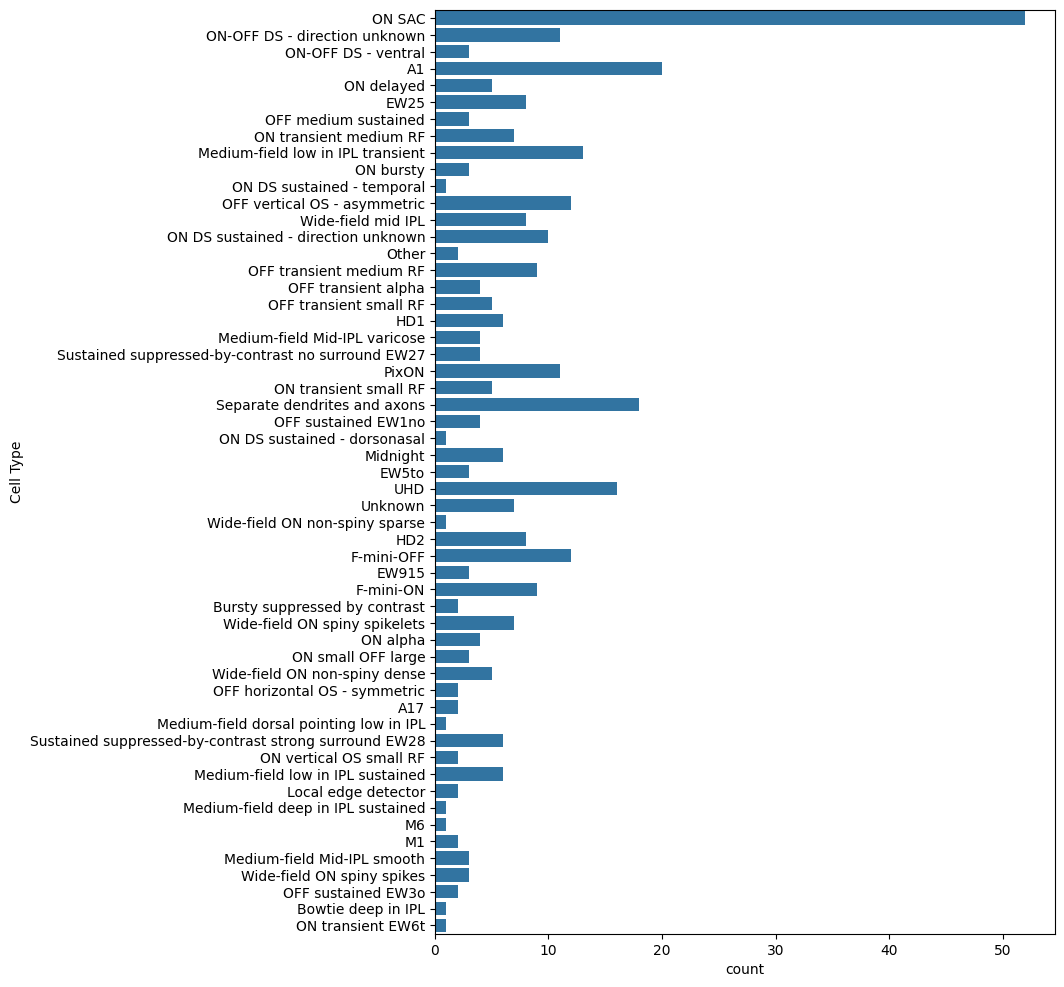

In [6]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df, y='Cell Type')
plt.show()

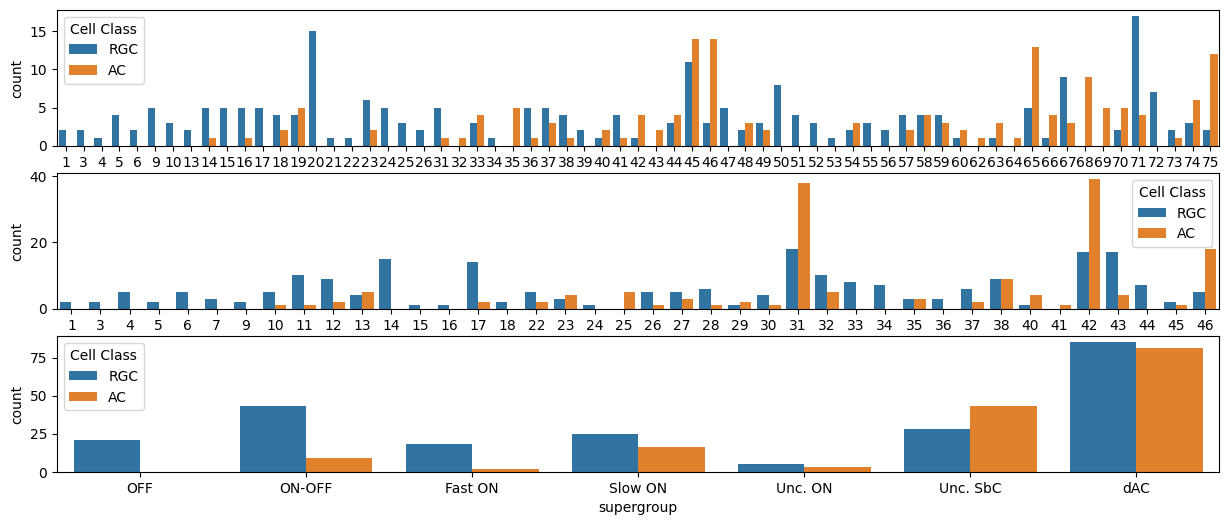

In [22]:
fig, ax = plt.subplots(3, 1, figsize=(15, 6))
sns.countplot(ax=ax[0], data=df, x='cluster_id', hue='Cell Class', hue_order=['RGC', 'AC'])
sns.countplot(ax=ax[1], data=df, x='group_id', hue='Cell Class', hue_order=['RGC', 'AC'])
sns.countplot(ax=ax[2], data=df, x='supergroup', hue='Cell Class', hue_order=['RGC', 'AC'],
              order=['OFF', 'ON-OFF', 'Fast ON', 'Slow ON', 'Unc. ON', 'Unc. SbC', 'dAC'])
plt.show()